In [2]:
"""
CycleGAN monet2photo 完整实验代码 - Google Colab 专用版
功能：环境配置、数据集下载、模型训练（含断点恢复）、推理测试
运行前请先连接 Colab 的 GPU 运行时
"""

import os
import subprocess
import shutil
import torch
from google.colab import drive

# ========================= 第1部分：配置检测和安装依赖 =========================
print("===== 第1步: 配置检测和安装依赖 =====")

# 检测GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用的设备: {device}")

# 挂载Google Drive，模型和数据都会保存在这里，防止Colab断开时丢失
drive.mount('/content/drive')

# 设置工作目录（在Google Drive中创建项目文件夹）
PROJECT_DIR = '/content/drive/MyDrive/cyclegan_monet2photo'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print(f"工作目录已切换到: {PROJECT_DIR}")

# 克隆 CycleGAN 官方代码库
repo_path = f'{PROJECT_DIR}/pytorch-CycleGAN-and-pix2pix'
if not os.path.exists(repo_path):
    print("正在克隆CycleGAN官方代码库...")
    subprocess.run(['git', 'clone', 'https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git'], check=True)
else:
    print("CycleGAN代码库已存在，跳过克隆。")

# 安装依赖（如果尚未安装）
try:
    import dominate
    import visdom
    print("依赖库 bereits installiert.")
except ImportError:
    print("正在安装依赖库...")
    subprocess.run(['pip', 'install', 'dominate', 'visdom'], check=True)
    print("依赖库安装完成。")

# 切换到项目代码目录
os.chdir(repo_path)
print(f"当前代码目录: {os.getcwd()}")

===== 第1步: 配置检测和安装依赖 =====
使用的设备: cuda
Mounted at /content/drive
工作目录已切换到: /content/drive/MyDrive/cyclegan_monet2photo
CycleGAN代码库已存在，跳过克隆。
正在安装依赖库...
依赖库安装完成。
当前代码目录: /content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix


In [ ]:
import os

# 先切换到项目根目录（根据你的实际路径）
os.chdir("/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix")

# 检查 monet2photo 数据集各文件夹中的图片数量
for folder in ["trainA", "trainB", "testA", "testB"]:
    path = f"datasets/monet2photo/{folder}"
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.png'))])
        print(f"{folder}: {count} 张图片")
    else:
        print(f"{folder}: 文件夹不存在，请检查路径")

trainA: 1072 张图片
trainB: 6287 张图片
testA: 121 张图片
testB: 751 张图片


建立mini数据集

In [ ]:
import os
import shutil
import glob

# 确保在项目根目录
os.chdir("/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix")
print("当前目录:", os.getcwd())

# 定义 mini 数据集的路径（从完整数据中各取 200 张训练图，50 张测试图）
mini_root = "datasets/monet2photo_mini"
if not os.path.exists(mini_root):
    os.makedirs(f"{mini_root}/trainA", exist_ok=True)
    os.makedirs(f"{mini_root}/trainB", exist_ok=True)
    os.makedirs(f"{mini_root}/testA", exist_ok=True)
    os.makedirs(f"{mini_root}/testB", exist_ok=True)

    # 源数据路径（根据实际结构调整，如果 monet2photo 目录不存在，可能是 monet2photo (1)）
    src_root = "datasets/monet2photo"
    if not os.path.isdir(src_root):
        # 尝试查找以 monet2photo 开头的目录
        import glob as g
        candidates = [d for d in os.listdir("datasets") if d.startswith("monet2photo") and os.path.isdir(os.path.join("datasets", d))]
        if candidates:
            src_root = os.path.join("datasets", candidates[0])
            print(f"使用源目录: {src_root}")
        else:
            raise FileNotFoundError("未找到 monet2photo 数据集目录")

    # 复制训练集前200张
    trainA = sorted(glob.glob(f"{src_root}/trainA/*.jpg"))[:200]
    trainB = sorted(glob.glob(f"{src_root}/trainB/*.jpg"))[:200]
    testA = sorted(glob.glob(f"{src_root}/testA/*.jpg"))[:50]
    testB = sorted(glob.glob(f"{src_root}/testB/*.jpg"))[:50]

    for f in trainA:
        shutil.copy(f, f"{mini_root}/trainA/")
    for f in trainB:
        shutil.copy(f, f"{mini_root}/trainB/")
    for f in testA:
        shutil.copy(f, f"{mini_root}/testA/")
    for f in testB:
        shutil.copy(f, f"{mini_root}/testB/")

    print(f"mini 数据集创建完成，共 {len(trainA)} 张 trainA，{len(trainB)} 张 trainB，{len(testA)} 张 testA，{len(testB)} 张 testB")
else:
    print("mini 数据集已存在，跳过创建")

当前目录: /content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix
mini 数据集创建完成，共 200 张 trainA，200 张 trainB，50 张 testA，50 张 testB


模型训练

In [ ]:
import os
import re
import subprocess
import sys

# 1. 配置路径
os.environ["PYTHONUNBUFFERED"] = "1"
project_path = "/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix"
os.chdir(project_path)

experiment_name = "monet2photo_cyclegan"
checkpoints_dir = "checkpoints"
dataroot = "datasets/monet2photo_mini"

# 2. 自动检测断点（仅依赖 loss_log.txt 的正确解析）
continue_train = False
epoch_count = 1
loss_log_path = f"{checkpoints_dir}/{experiment_name}/loss_log.txt"

def get_last_epoch_from_log(log_path):
    """从 loss_log.txt 中提取最后一个 epoch 编号，失败返回 None"""
    if not os.path.exists(log_path):
        return None
    with open(log_path, 'r') as f:
        # 从后往前读，提高效率
        for line in reversed(f.readlines()):
            match = re.search(r'\(epoch:\s*(\d+)', line)
            if match:
                return int(match.group(1))
    return None

last_epoch = get_last_epoch_from_log(loss_log_path)
if last_epoch is not None:
    epoch_count = last_epoch + 1
    continue_train = True
    print(f"检测到有效训练日志，最后一个 epoch = {last_epoch}，将从 epoch {epoch_count} 继续训练")
else:
    print("未检测到有效训练日志（文件不存在或无法解析），开始全新训练")

# 3. 构建训练命令
train_cmd = [
    "python", "-u", "train.py",
    "--dataroot", dataroot,
    "--name", experiment_name,
    "--model", "cycle_gan",
    "--batch_size", "4",
    "--n_epochs", "20",
    "--n_epochs_decay", "20",
    "--lr", "0.0002",
    "--save_epoch_freq", "5",
    "--checkpoints_dir", checkpoints_dir,
    "--print_freq", "10"
]

if continue_train:
    train_cmd.extend(["--continue_train", "--epoch_count", str(epoch_count)])

print("\n执行命令:", " ".join(train_cmd), "\n")

# 4. 实时执行并捕获输出
process = subprocess.Popen(
    train_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

try:
    for line in iter(process.stdout.readline, ''):
        sys.stdout.write(line)
        sys.stdout.flush()
except KeyboardInterrupt:
    print("\n[用户中断] 正在停止训练进程...")
    process.terminate()
finally:
    process.wait()
    print("\n训练进程已退出。")

未检测到有效训练日志（文件不存在或无法解析），开始全新训练

执行命令: python -u train.py --dataroot datasets/monet2photo_mini --name monet2photo_cyclegan --model cycle_gan --batch_size 4 --n_epochs 20 --n_epochs_decay 20 --lr 0.0002 --save_epoch_freq 5 --checkpoints_dir checkpoints --print_freq 10 

----------------- Options ---------------
               batch_size: 4                             	[default: 1]
                    beta1: 0.5                           
          checkpoints_dir: checkpoints                   	[default: ./checkpoints]
           continue_train: False                         
                crop_size: 256                           
                 dataroot: datasets/monet2photo_mini     	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                       

In [3]:
import os, re
log_path = "checkpoints/monet2photo_cyclegan/loss_log.txt"
if os.path.exists(log_path):
    with open(log_path) as f:
        for line in reversed(f.readlines()):
            m = re.search(r'\(epoch:\s*(\d+)', line)
            if m:
                print("最后一个 epoch 是:", m.group(1))
                break
else:
    print("日志文件不存在")

最后一个 epoch 是: 31


In [4]:
# -*- coding: utf-8 -*-
"""
CycleGAN 续训到 100 epochs - Google Colab
基于现有模型（已训练 30 epochs）继续训练至 100 epochs
"""

import os
import re
import subprocess
import sys
from google.colab import drive

# ================== 1. 挂载 Drive 并切换到项目目录 ==================
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix'
os.chdir(PROJECT_DIR)
print(f"当前工作目录: {os.getcwd()}")

# 确保依赖已安装（如果未安装）
!pip install dominate visdom -q

# ================== 2. 配置训练参数 ==================
experiment_name = "monet2photo_cyclegan"
checkpoints_dir = "checkpoints"
dataroot = "datasets/monet2photo_mini"   # 使用 mini 数据集

# 新总轮次：100 = 50 + 50
n_epochs = 50
n_epochs_decay = 50

# ================== 3. 自动检测断点 ==================
continue_train = False
epoch_count = 1
loss_log_path = f"{checkpoints_dir}/{experiment_name}/loss_log.txt"

def get_last_epoch_from_log(log_path):
    """从 loss_log.txt 中提取最后一个 epoch 编号，失败返回 None"""
    if not os.path.exists(log_path):
        return None
    with open(log_path, 'r') as f:
        # 从后往前读
        for line in reversed(f.readlines()):
            match = re.search(r'\(epoch:\s*(\d+)', line)
            if match:
                return int(match.group(1))
    return None

last_epoch = get_last_epoch_from_log(loss_log_path)
if last_epoch is not None:
    epoch_count = last_epoch + 1
    continue_train = True
    print(f" 检测到有效训练日志，最后一个 epoch = {last_epoch}，将从 epoch {epoch_count} 继续训练")
else:
    print(" 未检测到有效训练日志，将开始全新训练（如果模型已存在可能覆盖）")

# ================== 4. 构建训练命令（续训 + 新总轮次） ==================
train_cmd = [
    "python", "-u", "train.py",
    "--dataroot", dataroot,
    "--name", experiment_name,
    "--model", "cycle_gan",
    "--batch_size", "4",
    "--n_epochs", str(n_epochs),
    "--n_epochs_decay", str(n_epochs_decay),
    "--lr", "0.0002",
    "--save_epoch_freq", "5",
    "--checkpoints_dir", checkpoints_dir,
    "--print_freq", "10"
]

if continue_train:
    train_cmd.extend(["--continue_train", "--epoch_count", str(epoch_count)])

print("\n 执行训练命令:\n", " ".join(train_cmd), "\n")

# ================== 5. 实时执行并捕获输出 ==================
process = subprocess.Popen(
    train_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

try:
    for line in iter(process.stdout.readline, ''):
        sys.stdout.write(line)
        sys.stdout.flush()
except KeyboardInterrupt:
    print("\n[用户中断] 正在停止训练进程...")
    process.terminate()
finally:
    process.wait()
    print("\n训练进程已退出。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
当前工作目录: /content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix
 检测到有效训练日志，最后一个 epoch = 31，将从 epoch 32 继续训练

 执行训练命令:
 python -u train.py --dataroot datasets/monet2photo_mini --name monet2photo_cyclegan --model cycle_gan --batch_size 4 --n_epochs 50 --n_epochs_decay 50 --lr 0.0002 --save_epoch_freq 5 --checkpoints_dir checkpoints --print_freq 10 --continue_train --epoch_count 32 

----------------- Options ---------------
               batch_size: 4                             	[default: 1]
                    beta1: 0.5                           
          checkpoints_dir: checkpoints                   	[default: ./checkpoints]
           continue_train: True                          	[default: False]
                crop_size: 256                           
                 dataroot: datasets/monet2photo_mini     	[default: None]
         

测试模型：

In [ ]:
import os
import subprocess

os.chdir("/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix")

# 检查模型文件是否存在（可选）
model_file = "checkpoints/monet2photo_cyclegan/30_net_G_A.pth"
if not os.path.exists(model_file):
    print(f"⚠️ 模型文件 {model_file} 不存在，将使用 latest 模型。")
    epoch_arg = "latest"
else:
    epoch_arg = "30"

test_cmd = [
    "python", "test.py",
    "--dataroot", "datasets/monet2photo_mini",   # 指向根目录，不要加 /testA
    "--name", "monet2photo_cyclegan",
    "--model", "cycle_gan",
    "--epoch", epoch_arg,                       # 使用 latest 或 30
    "--num_test", "20",
    "--results_dir", "results"
]

print("执行命令:", " ".join(test_cmd))
result = subprocess.run(test_cmd)
if result.returncode == 0:
    print("测试完成，生成图片保存在 results/monet2photo_cyclegan/test_{}/images/".format(epoch_arg))
else:
    print("测试失败，请检查错误信息。")

执行命令: python test.py --dataroot datasets/monet2photo_mini --name monet2photo_cyclegan --model cycle_gan --epoch 30 --num_test 20 --results_dir results
测试完成，生成图片保存在 results/monet2photo_cyclegan/test_30/images/


In [5]:
import os
import subprocess

os.chdir("/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix")

# 直接使用 100 epoch 模型
epoch_arg = "100"

test_cmd = [
    "python", "test.py",
    "--dataroot", "datasets/monet2photo_mini",
    "--name", "monet2photo_cyclegan",
    "--model", "cycle_gan",
    "--epoch", epoch_arg,
    "--num_test", "20",
    "--results_dir", "results"
]

print("执行命令:", " ".join(test_cmd))
result = subprocess.run(test_cmd)
if result.returncode == 0:
    print(f"测试完成，生成图片保存在 results/monet2photo_cyclegan/test_{epoch_arg}/images/")
else:
    print("测试失败，请检查错误信息。")

执行命令: python test.py --dataroot datasets/monet2photo_mini --name monet2photo_cyclegan --model cycle_gan --epoch 100 --num_test 20 --results_dir results
测试完成，生成图片保存在 results/monet2photo_cyclegan/test_100/images/


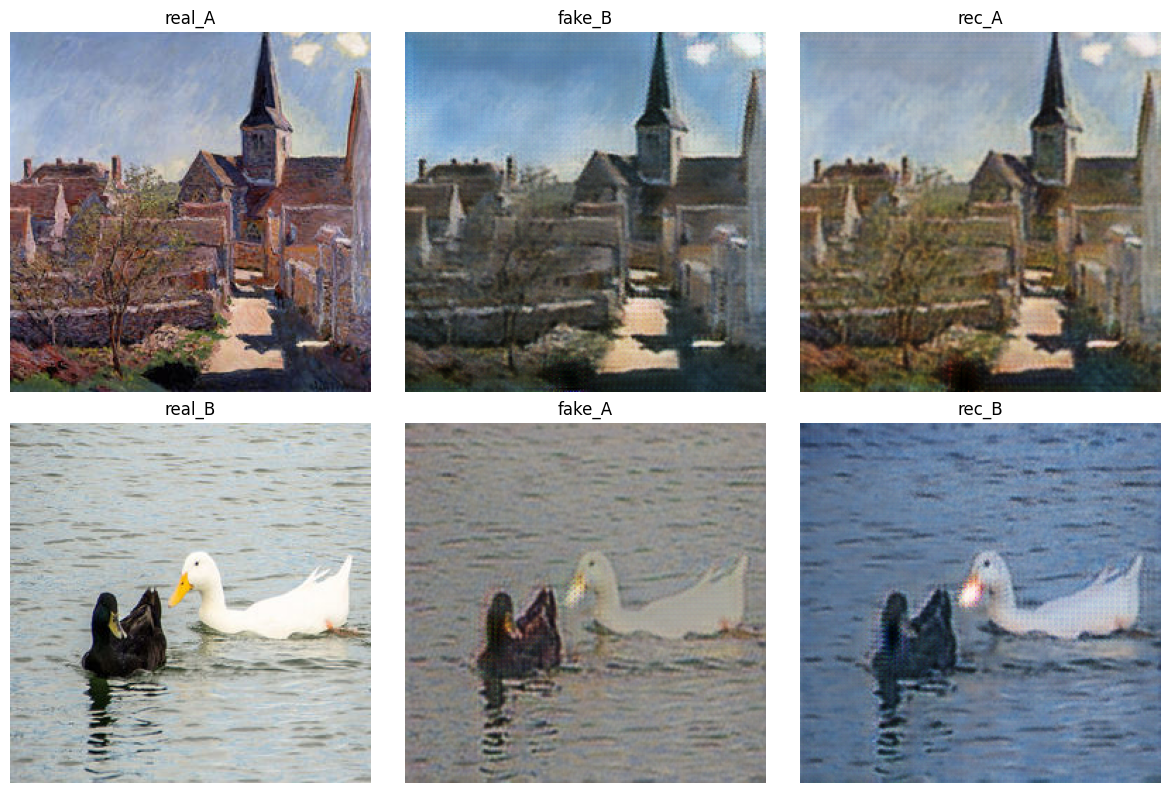

In [37]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

img_dir = './results/monet2photo_cyclegan/test_100/images'
images = sorted(os.listdir(img_dir))

target_prefix = '00060'
target_images = [f for f in images if target_prefix in f]

# 期望顺序：real_A -> fake_B -> rec_A -> real_B -> fake_A -> rec_B
order = ['real_A', 'fake_B', 'rec_A', 'real_B', 'fake_A', 'rec_B']

# 根据 order 排序
sorted_images = []
for suffix in order:
    for f in target_images:
        if suffix in f:
            sorted_images.append(f)
            break

# 绘图：2行3列
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# 将 axes 展平为一维以便循环
axes_flat = axes.flatten()

for i, img_name in enumerate(sorted_images):
    img = mpimg.imread(os.path.join(img_dir, img_name))
    axes_flat[i].imshow(img)
    axes_flat[i].axis('off')
    # 显示简短标题（去掉前缀和扩展名）
    short_title = img_name.split('_', 1)[1].replace('.png', '')
    axes_flat[i].set_title(short_title)

plt.tight_layout()
plt.show()

使用自己训练的模型进行单张图像推理

请选择你要转换的风景图片:


Saving 270783bfd8948bf5bebb4b07dd2da9cdce700955.jpg to 270783bfd8948bf5bebb4b07dd2da9cdce700955.jpg

 正在进行模型推理...
 推理完成！


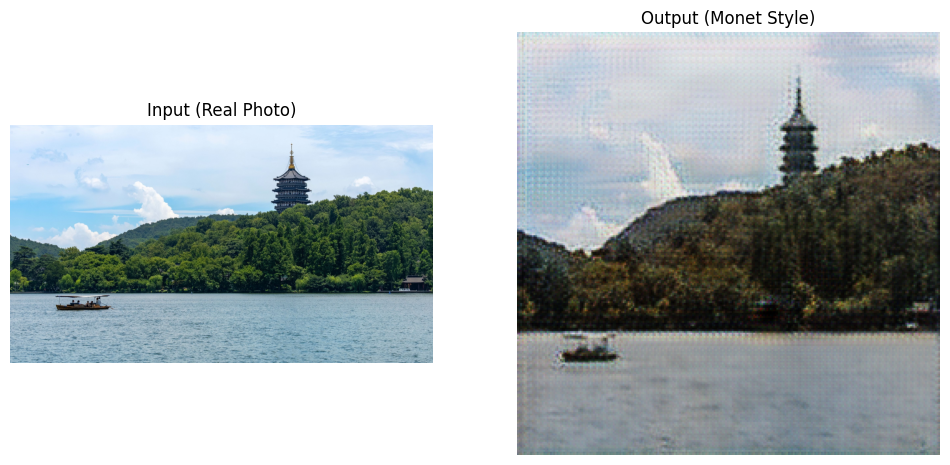

In [8]:
import os
import shutil
import subprocess
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import files

# ================= 1. 上传图片 =================
print("请选择你要转换的风景图片:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ================= 2. 准备工作 =================
project_dir = "/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix"
os.chdir(project_dir)

# 创建推理用的临时目录
infer_root = "/content/inference_tmp"
infer_testA = os.path.join(infer_root, "testA")
infer_testB = os.path.join(infer_root, "testB") # CycleGAN需要testB

# 清理旧数据
if os.path.exists(infer_root): shutil.rmtree(infer_root)
os.makedirs(infer_testA, exist_ok=True)
os.makedirs(infer_testB, exist_ok=True)

# 将图片移动到 testA (作为输入)
img_path = os.path.join(infer_testA, filename)
shutil.move(filename, img_path)

# 在 testB 中放一个同样的图片作为占位符，满足代码检查
shutil.copy(img_path, os.path.join(infer_testB, "dummy.jpg"))

# ================= 3. 执行推理 =================
print("\n 正在进行模型推理...")

test_cmd = [
    "python", "test.py",
    "--dataroot", infer_root,               # 指向包含 testA 和 testB 的父目录
    "--name", "monet2photo_cyclegan",       # 模型名称
    "--model", "cycle_gan",                 # 使用 cycle_gan 模式
    "--direction", "AtoB",                  # A 转 B
    "--epoch", "latest",
    "--num_test", "1",
    "--no_dropout",
    "--results_dir", "./results_inference"
]

result = subprocess.run(test_cmd, capture_output=True, text=True)

if result.returncode == 0:
    print(" 推理完成！")

    # ================= 4. 显示结果 =================
    name_no_ext = os.path.splitext(filename)[0]
    # CycleGAN 默认生成的结果路径格式
    output_path = os.path.join(project_dir, "results_inference", "monet2photo_cyclegan", "test_latest", "images", f"{name_no_ext}_fake_B.png")

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # 显示原图
    img_in = mpimg.imread(img_path)
    axes[0].imshow(img_in)
    axes[0].set_title("Input (Real Photo)")
    axes[0].axis('off')

    # 显示结果图
    if os.path.exists(output_path):
        img_out = mpimg.imread(output_path)
        axes[1].imshow(img_out)
        axes[1].set_title("Output (Monet Style)")
        axes[1].axis('off')
    else:
        print(f" 错误: 未找到生成的图片，路径为 {output_path}")

    plt.show()
else:
    print(" 推理失败，错误日志：")
    print(result.stdout)
    print(result.stderr)

请选择你要转换的图片:


Saving 00200_real_A.png to 00200_real_A.png

请选择转换方向：
1. 照片 → 莫奈风格 (Photo to Monet)  【仅使用自己训练的模型】
2. 莫奈画作 → 照片 (Monet to Photo)  【对比：自己模型 vs 预训练模型】
请输入数字 1 或 2: 2

方向：莫奈 → 照片 (对比自己模型 vs 预训练模型)
自己模型命令: python test.py --dataroot /content/inference_tmp_1778916556158 --name monet2photo_cyclegan --model cycle_gan --direction BtoA --epoch latest --num_test 1 --no_dropout --results_dir ./results_self_compare
预训练模型命令: python test.py --dataroot /content/test_input_1778916563935 --name monet2photo_pretrained --model test --no_dropout --results_dir ./results_pretrain
预训练模型推理成功
标准输出: ----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/test_input_1778916563935	[default: None]
             dataset_mode: single                        
            

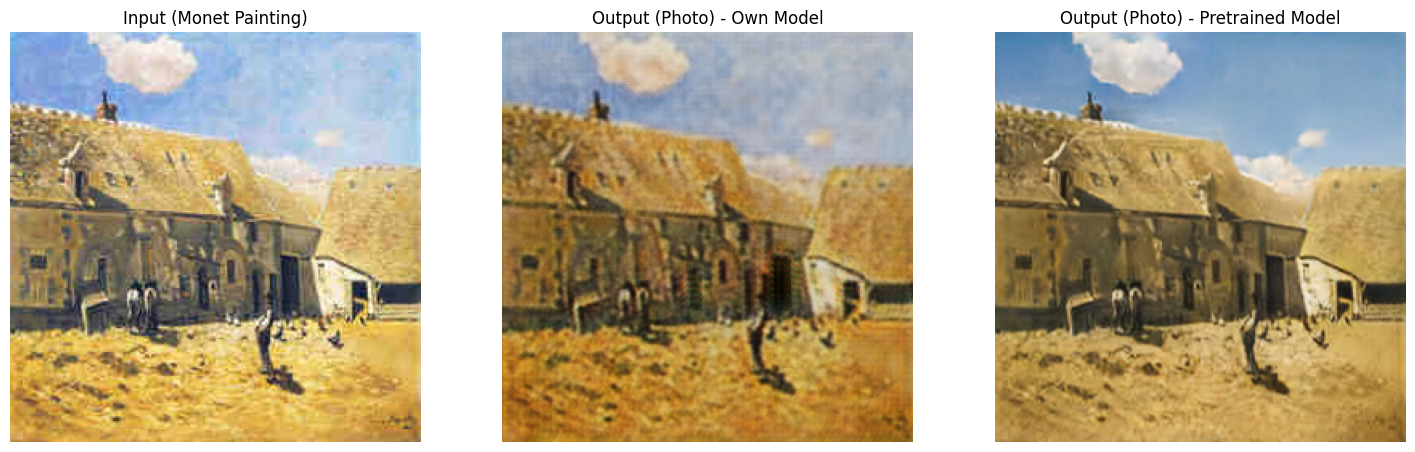

In [40]:
import os
import shutil
import subprocess
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import files
import time

# ================= 1. 上传图片 =================
print("请选择你要转换的图片:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ================= 2. 选择转换方向 =================
print("\n请选择转换方向：")
print("1. 照片 → 莫奈风格 (Photo to Monet)  【仅使用自己训练的模型】")
print("2. 莫奈画作 → 照片 (Monet to Photo)  【对比：自己模型 vs 预训练模型】")
choice = input("请输入数字 1 或 2: ").strip()

project_dir = "/content/drive/MyDrive/cyclegan_monet2photo/pytorch-CycleGAN-and-pix2pix"
os.chdir(project_dir)

# ================= 3. 辅助函数 =================
def prepare_temp_dataset_cyclegan(input_img_path, input_domain):
    """为 cycle_gan 模式准备临时目录（需要 testA 和 testB）"""
    unique_id = str(int(time.time() * 1000))
    infer_root = f"/content/inference_tmp_{unique_id}"
    os.makedirs(os.path.join(infer_root, "testA"), exist_ok=True)
    os.makedirs(os.path.join(infer_root, "testB"), exist_ok=True)

    img_basename = os.path.basename(input_img_path)
    target_path = os.path.join(infer_root, input_domain, img_basename)
    shutil.copy(input_img_path, target_path)
    # 在另一个域放占位符
    placeholder_domain = "testB" if input_domain == "testA" else "testA"
    placeholder_path = os.path.join(infer_root, placeholder_domain, "dummy.jpg")
    shutil.copy(input_img_path, placeholder_path)
    return infer_root, target_path

def prepare_temp_dataset_test(input_img_path):
    """为 test 模式准备临时目录（只需要一个目录，不分子目录）"""
    unique_id = str(int(time.time() * 1000))
    infer_root = f"/content/test_input_{unique_id}"
    os.makedirs(infer_root, exist_ok=True)
    target_path = os.path.join(infer_root, os.path.basename(input_img_path))
    shutil.copy(input_img_path, target_path)
    return infer_root, target_path

# ================= 4. 根据选择执行 =================
if choice == '1':
    # 照片 → 莫奈：只用自己模型 (AtoB)
    print("\n方向：照片 → 莫奈 (仅使用自己训练的模型)")
    infer_root, img_path = prepare_temp_dataset_cyclegan(filename, "testA")
    cmd_self = [
        "python", "test.py",
        "--dataroot", infer_root,
        "--name", "monet2photo_cyclegan",
        "--model", "cycle_gan",
        "--direction", "AtoB",
        "--epoch", "latest",
        "--num_test", "1",
        "--no_dropout",
        "--results_dir", "./results_self"
    ]
    print("运行命令:", " ".join(cmd_self))
    subprocess.run(cmd_self, capture_output=True, text=True)
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    # 输出路径规则：results_self/{model_name}/test_latest/images/{base_name}_fake_B.png
    result_self = os.path.join(project_dir, "results_self", "monet2photo_cyclegan", "test_latest", "images", f"{base_name}_fake_B.png")
    # 显示
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    img_in = mpimg.imread(img_path)
    axes[0].imshow(img_in)
    axes[0].set_title("Input (Photo)")
    axes[0].axis('off')
    if os.path.exists(result_self):
        img_out = mpimg.imread(result_self)
        axes[1].imshow(img_out)
        axes[1].set_title("Output (Monet Style) - Own Model")
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, "Result not found", ha='center')
        print(f"结果不存在: {result_self}")
    plt.show()

elif choice == '2':
    # 莫奈 → 照片：对比自己模型 (BtoA) 和预训练模型 (test 模式)
    print("\n方向：莫奈 → 照片 (对比自己模型 vs 预训练模型)")

    # ----- 自己模型 (cycle_gan, BtoA) -----
    infer_root_self, img_path_self = prepare_temp_dataset_cyclegan(filename, "testB")
    cmd_self = [
        "python", "test.py",
        "--dataroot", infer_root_self,
        "--name", "monet2photo_cyclegan",
        "--model", "cycle_gan",
        "--direction", "BtoA",
        "--epoch", "latest",
        "--num_test", "1",
        "--no_dropout",
        "--results_dir", "./results_self_compare"
    ]
    print("自己模型命令:", " ".join(cmd_self))
    subprocess.run(cmd_self, capture_output=True, text=True)
    base_name_self = os.path.splitext(os.path.basename(img_path_self))[0]
    result_self = os.path.join(project_dir, "results_self_compare", "monet2photo_cyclegan", "test_latest", "images", f"{base_name_self}_fake_A.png")

    # ----- 预训练模型 (test 模式，使用简单输入目录) -----
    # 确保预训练模型文件存在
    pretrain_ckpt = "checkpoints/monet2photo_pretrained"
    if not os.path.exists(os.path.join(pretrain_ckpt, "latest_net_G.pth")):
        print("预训练模型不存在，正在下载...")
        subprocess.run(["bash", "./scripts/download_cyclegan_model.sh", "monet2photo"])
    # 准备输入目录（无需子目录）
    infer_root_pretrain, img_path_pretrain = prepare_temp_dataset_test(filename)
    cmd_pretrain = [
        "python", "test.py",
        "--dataroot", infer_root_pretrain,
        "--name", "monet2photo_pretrained",
        "--model", "test",
        "--no_dropout",
        "--results_dir", "./results_pretrain"
    ]
    print("预训练模型命令:", " ".join(cmd_pretrain))
    result_pretrain_run = subprocess.run(cmd_pretrain, capture_output=True, text=True)
    if result_pretrain_run.returncode != 0:
        print("预训练模型推理失败，错误信息:")
        print(result_pretrain_run.stderr)
    else:
        print("预训练模型推理成功")
        print("标准输出:", result_pretrain_run.stdout)
        print("标准错误:", result_pretrain_run.stderr)
    # 注意：test 模式下输出路径为 {results_dir}/{name}/test_latest/images/{base_name}_fake.png
    base_name_pretrain = os.path.splitext(os.path.basename(img_path_pretrain))[0]
    result_pretrain = os.path.join(project_dir, "results_pretrain", "monet2photo_pretrained", "test_latest", "images", f"{base_name_pretrain}_fake.png")
    print(f"期望的预训练结果路径: {result_pretrain}")

    # 如果结果不存在，列出目录内容帮助诊断
    if not os.path.exists(result_pretrain):
        print("预训练结果未找到，检查目录内容:")
        list_dir = os.path.join(project_dir, "results_pretrain", "monet2photo_pretrained", "test_latest", "images")
        if os.path.exists(list_dir):
            print("目录内容:", os.listdir(list_dir))
        else:
            print(f"目录不存在: {list_dir}")
            # 尝试查找 results_pretrain 下是否有其他子目录
            if os.path.exists(os.path.join(project_dir, "results_pretrain")):
                print("results_pretrain 内容:", os.listdir(os.path.join(project_dir, "results_pretrain")))

    # 显示三列对比
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    img_in = mpimg.imread(img_path_self)
    axes[0].imshow(img_in)
    axes[0].set_title("Input (Monet Painting)")
    axes[0].axis('off')

    if os.path.exists(result_self):
        img_self = mpimg.imread(result_self)
        axes[1].imshow(img_self)
        axes[1].set_title("Output (Photo) - Own Model")
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, "Own Model Result Not Found", ha='center')
        print(f"自己模型结果不存在: {result_self}")

    if os.path.exists(result_pretrain):
        img_pretrain = mpimg.imread(result_pretrain)
        axes[2].imshow(img_pretrain)
        axes[2].set_title("Output (Photo) - Pretrained Model")
        axes[2].axis('off')
    else:
        axes[2].text(0.5, 0.5, "Pretrained Model Result Not Found", ha='center')

    plt.show()
else:
    print("无效选择，请重新运行。")

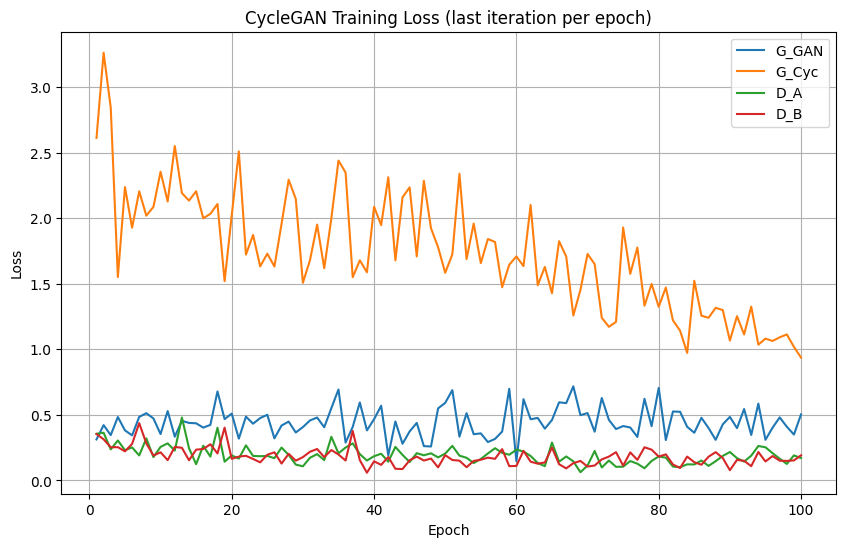

In [33]:
import re
import matplotlib.pyplot as plt

log_path = "checkpoints/monet2photo_cyclegan/loss_log.txt"

epochs = []
g_gan = []
g_cyc = []
d_a = []
d_b = []

with open(log_path, 'r') as f:
    for line in f:
        # 跳过表头
        if line.startswith('==='):
            continue
        # 匹配包含损失数值的行
        # 示例: [Rank 0] (epoch: 1, iters: 20, time: 0.564, data: 0.621) , D_A: 2.587, G_A: 3.491, cycle_A: 4.705, idt_A: 2.867, D_B: 1.868, G_B: 2.024, cycle_B: 5.381, idt_B: 2.376
        match = re.search(r'\(epoch:\s*(\d+).*?\)\s*, D_A:\s*([\d.]+), G_A:\s*([\d.]+), cycle_A:\s*([\d.]+), idt_A:\s*[\d.]+,\s*D_B:\s*([\d.]+), G_B:\s*[\d.]+,\s*cycle_B:\s*[\d.]+,\s*idt_B:\s*[\d.]+', line)
        if match:
            epoch = int(match.group(1))
            d_a_val = float(match.group(2))
            g_gan_val = float(match.group(3))
            g_cyc_val = float(match.group(4))
            d_b_val = float(match.group(5))
            epochs.append(epoch)
            d_a.append(d_a_val)
            g_gan.append(g_gan_val)
            g_cyc.append(g_cyc_val)
            d_b.append(d_b_val)

# 按 epoch 分组，取每个 epoch 的最后一次记录（或平均值，这里取最后）
epoch_last = {}
for i, ep in enumerate(epochs):
    epoch_last[ep] = {'d_a': d_a[i], 'g_gan': g_gan[i], 'g_cyc': g_cyc[i], 'd_b': d_b[i]}

sorted_epochs = sorted(epoch_last.keys())
d_a_last = [epoch_last[ep]['d_a'] for ep in sorted_epochs]
g_gan_last = [epoch_last[ep]['g_gan'] for ep in sorted_epochs]
g_cyc_last = [epoch_last[ep]['g_cyc'] for ep in sorted_epochs]
d_b_last = [epoch_last[ep]['d_b'] for ep in sorted_epochs]

# 绘图
plt.figure(figsize=(10,6))
plt.plot(sorted_epochs, g_gan_last, label='G_GAN')
plt.plot(sorted_epochs, g_cyc_last, label='G_Cyc')
plt.plot(sorted_epochs, d_a_last, label='D_A')
plt.plot(sorted_epochs, d_b_last, label='D_B')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CycleGAN Training Loss (last iteration per epoch)')
plt.legend()
plt.grid(True)
plt.savefig('loss_curves.png', dpi=150)
plt.show()

预训练模型

In [10]:
# 下载预训练模型
!bash ./scripts/download_cyclegan_model.sh monet2photo

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [monet2photo]
for details.

--2026-05-16 05:34:00--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/monet2photo.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/monet2photo_pretrained/latest_net_G.pth’

./checkpoints/monet 100%[===================>]  43.46M  47.9MB/s    in 0.9s    

2026-05-16 05:34:01 (47.9 MB/s) - ‘./checkpoints/monet2photo_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [11]:
# 测试预训练模型（方向为monet2photo）
!python test.py --dataroot datasets/monet2photo_mini --name monet2photo_pretrained --model test --no_dropout

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/monet2photo_mini     	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             